# 1. Complex Numbers

## Why do complex numbers appear in control?

At first they may seem artificial:

$$ j = \sqrt{-1} $$

But they become extremely natural when dealing with systems whose dynamics involve:

$$ s = \sigma + j \omega $$

That single expression eventually gives us:

* poles
* zeros
* stability
* oscillations
* damping
* frequency response
* root locus
* Bode plots

So complex numbers aren't some unrelated mathematical prerequisite.

They are essentially the language in which we describe system dynamics

## Cartesian form

A complex number is written as

$$ z = a + jb $$

where:

* $a$: real part
* $b$: imaginary part
* $j = \sqrt{-1} $
	​


For example:

$$ z = 3 + j4 $$

We can represent:

$z=a+jb$

as a point:

$$ (a,b) $$

in the complex plane.

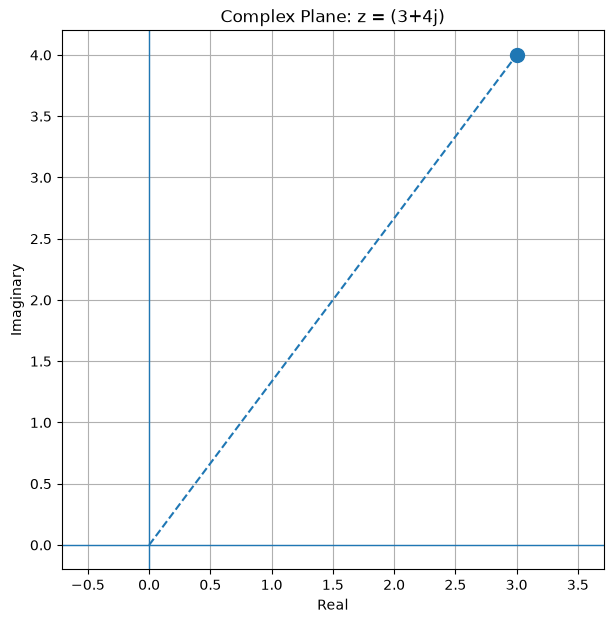

In [1]:
import matplotlib.pyplot as plt

# Complex number
z = 3 + 4j

# Coordinates
x = z.real
y = z.imag

# Plot
plt.figure(figsize=(7, 7))

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.scatter(x, y, s=100, zorder=3)
plt.plot([0, x], [0, y], linestyle="--")

# Labels
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title(f"Complex Plane: z = {z}")

# Keep aspect ratio equal
plt.axis("equal")
plt.grid(True)

plt.show()

## Magnitude

The magnitude of $z$ is:

$$
|z| = \sqrt{a^2 + b^2}
$$

For

$$ z = 3 + j4 $$

we get: 
$$
|z| = \sqrt{3^2 + 4^2} = 5
$$

This becomes extremely important in frequency response because we'll eventually calculate things such as:

$$
|G(j\omega)|
$$

which tells us the **gain of a system at a particular frequency**.

In python:

In [4]:
z = 3 + 4j

print(f" a = {z.real}")
print(f" b = {z.imag}")
print(f" |z| = {abs(z)}")

 a = 3.0
 b = 4.0
 |z| = 5.0


## Phase

The angle of the complex number is:

$$ \theta = \tan ^ - 1 \bigg( \dfrac{b}{a}\bigg) $$

For:

$$ z = 3 + j4 $$

$$ \theta = \tan ^ - 1 \bigg( \dfrac{4}{3}\bigg) $$
	​
approximately:

$$ θ=53.13 ° $$

So the same complex number can be represented geometrically as:

$$ z = 5 \angle 53.13° $$

Python:

In [6]:
import numpy as np

phase = np.angle(z)
phase_deg = np.degrees(phase)

print(f"\u03B8 = {phase_deg:.2f}°")

θ = 53.13°


## Polar form

This gives us:

$$ z=r(\cos \theta +j  \sin \theta) $$

where

$$ 
r=∣z∣
$$

and

$$θ=arg(z)$$

So:

$$ 3 + j4 = 5 (\cos 53.13° + j \sin 53.13°)$$

This form becomes particularly convenient for multiplication and division.

## Euler's formula

Now comes one of the most important equations in engineering mathematics:

$$ e ^{j \theta } = \cos \theta + j \sin \theta$$

Therefore:

$$ z = r e^{j\theta}$$

This is the exponential form of a complex number.

And this is where things start becoming very relevant to control.

Consider:

$$ e ^{j\omega t}$$

Using Euler:

$$ e^{jωt} = \cos(ωt)+j\sin(ωt) $$

The real component is a sinusoidal oscillation.

So complex exponentials provide a mathematically elegant way to represent oscillations.

Now consider:

$$ e^{(\sigma+j\omega)t} $$

We can separate it:

$$ e ^{(\sigma+j\omega)t} = e^{\sigma t} e^{j\omega t} $$

and therefore:

$$ e ^{(\sigma+j\omega)t} = e^{\sigma t} \bigg[ \cos(\omega t) + j \sin(\omega t) \bigg] $$


Look carefully at this.

$$ e^{\sigma t} $$

controls the amplitude.

$$\omega$$

controls the oscillation frequency.

Therefore:

$$s = \sigma+j\omega$$

contains two pieces of information:

* $\sigma$: Amplitude behavior
* $j\omega$: oscillation

This is one of the fundamental ideas behind pole locations.

If:

$$\sigma < 0$$

then:

$$e ^ {\sigma t}  \rightarrow 0$$

and the oscillation dies out.

If:

$$\sigma = 0$$

the oscillation persists.

If:

$$\sigma > 0$$

the amplitude grows.

And suddenly the complex plane becomes a stability map.

That's why we're reviewing complex numbers before differential equations.

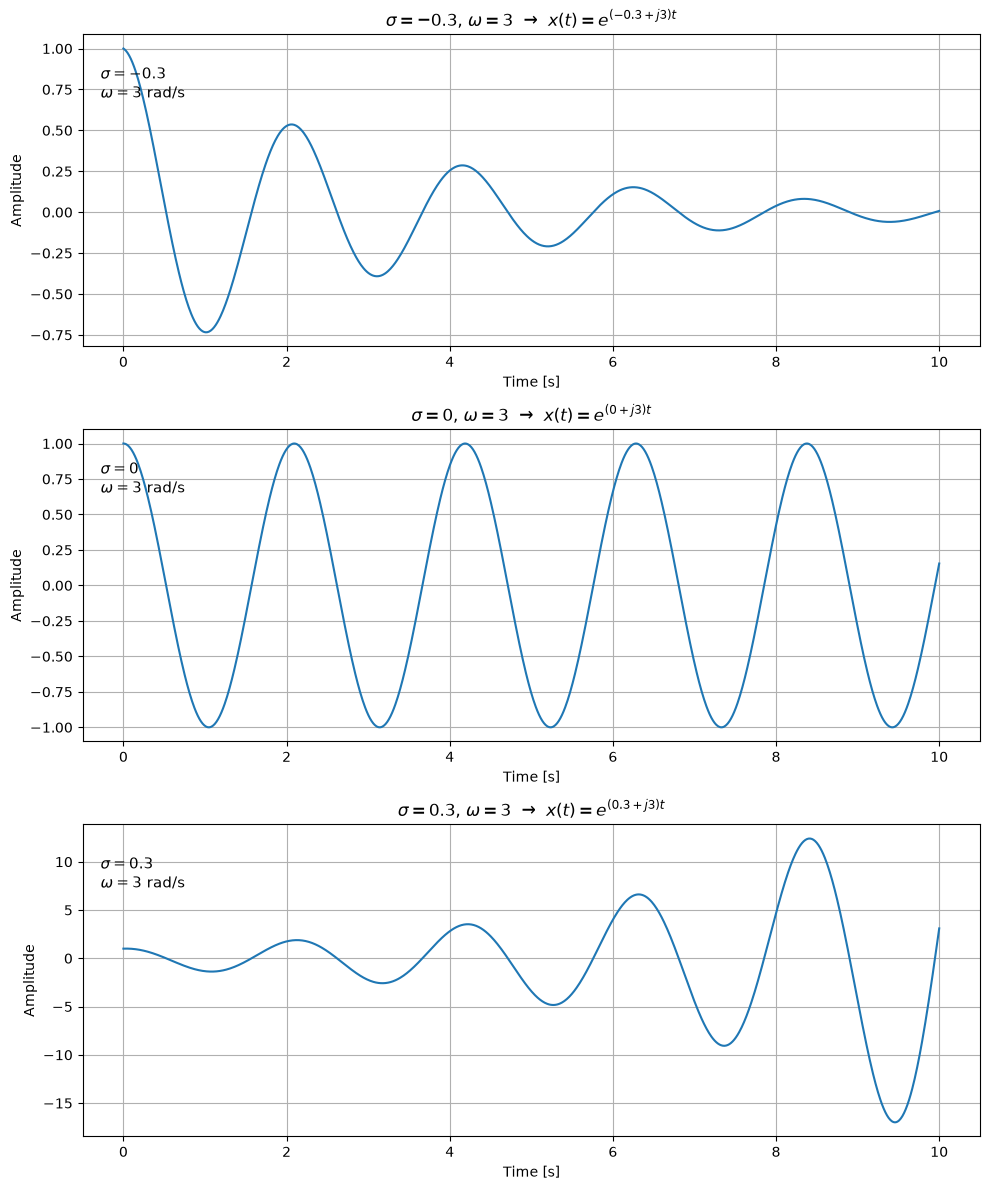

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Time
t = np.linspace(0, 10, 1000)

# Fixed angular frequency
omega = 3

# Three values of sigma
sigmas = [-0.3, 0, 0.3]

# Create 3 vertically stacked graphs
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for ax, sigma in zip(axes, sigmas):

    # Complex exponential
    x = np.exp((sigma + 1j * omega) * t)

    # Plot real part
    ax.plot(t, x.real)

    # Title
    ax.set_title(
        f"$\\sigma = {sigma}$, $\\omega = {omega}$  →  "
        f"$x(t) = e^{{({sigma} + j{omega})t}}$"
    )

    # Labels
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude")

    # Grid
    ax.grid(True)

    # Show sigma and omega inside graph
    ax.text(
        0.02, 0.90,
        f"$\\sigma = {sigma}$\n$\\omega = {omega}$ rad/s",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top"
    )

plt.tight_layout()
plt.show()